In [1]:
!hostnamectl

 Static hostname: gpue07.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: 5a02c0e14c05484e82dbc592d828c891
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: CUXD670_5.32_v2.06


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [2]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [ ]:
from utils import *

In [4]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [5]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/All_Cell_Types.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [11]:
rna_adata = sc.read_h5ad(rna_path_filtered)
rna_adata

AnnData object with n_obs × n_vars = 172396 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [12]:
# subset to samples of interest
rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

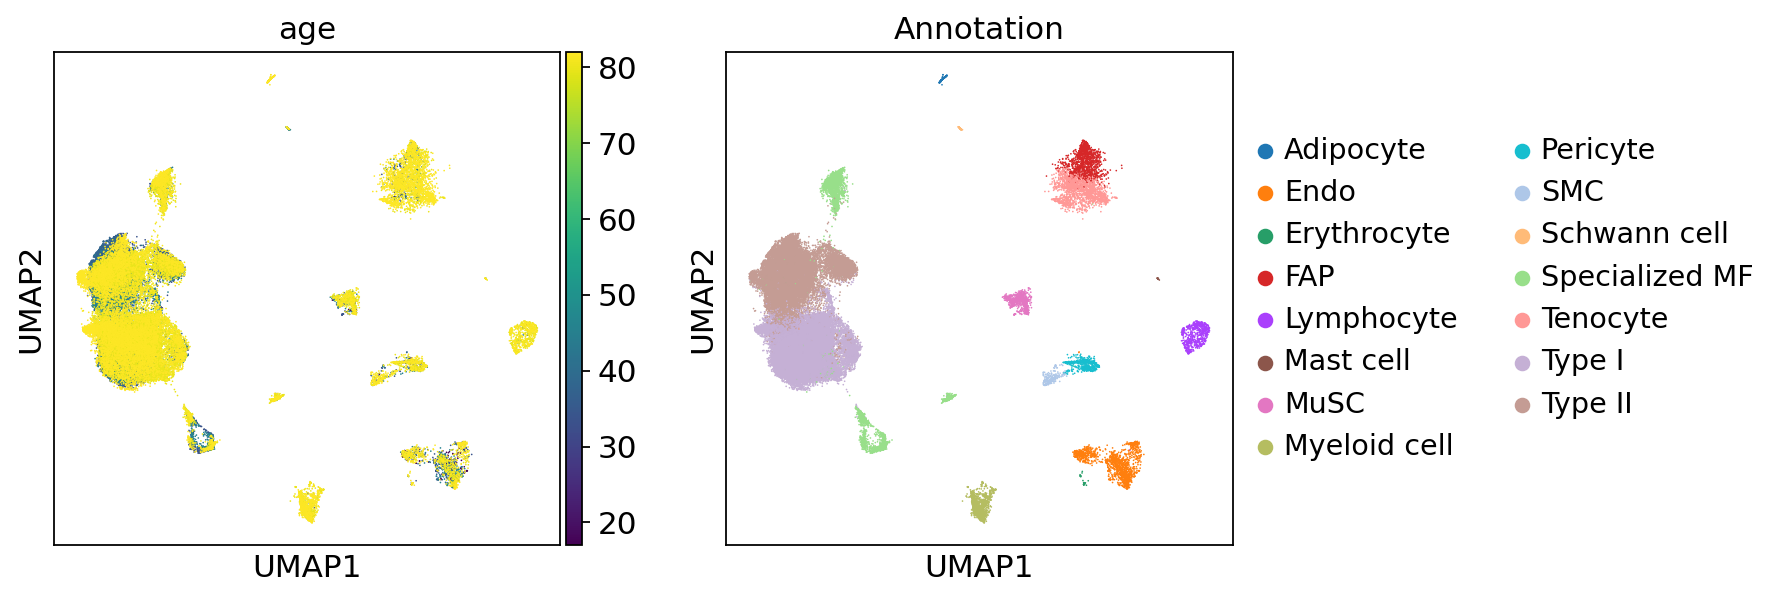

In [13]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [14]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'MuSC', 'FAP', 'Specialized MF'])].copy()

#### Lower bound on number of cells per age

In [15]:
# age_counts = rna_adata.obs['age'].value_counts()
# valid_ages = age_counts[age_counts >= 500].index

# rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # Verify
print(rna_adata.obs['age'].value_counts())

age
80.0    8448
45.0    6264
82.0    4633
34.0    2874
38.0    1967
17.0     305
Name: count, dtype: int64


#### Upper bound on number of cells per age

In [ ]:
# n_cells_downsample = 5000
# adatas = []

# for age, idx in rna_adata.obs.groupby('age').groups.items():
#     subset = rna_adata[idx].copy()
#     if subset.shape[0] > n_cells_downsample:
#         sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
#     adatas.append(subset)

# rna_adata = ad.concat(adatas)
# del adatas

# # Verify
# print(rna_adata.obs['age'].value_counts())

In [16]:
# # save 
rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

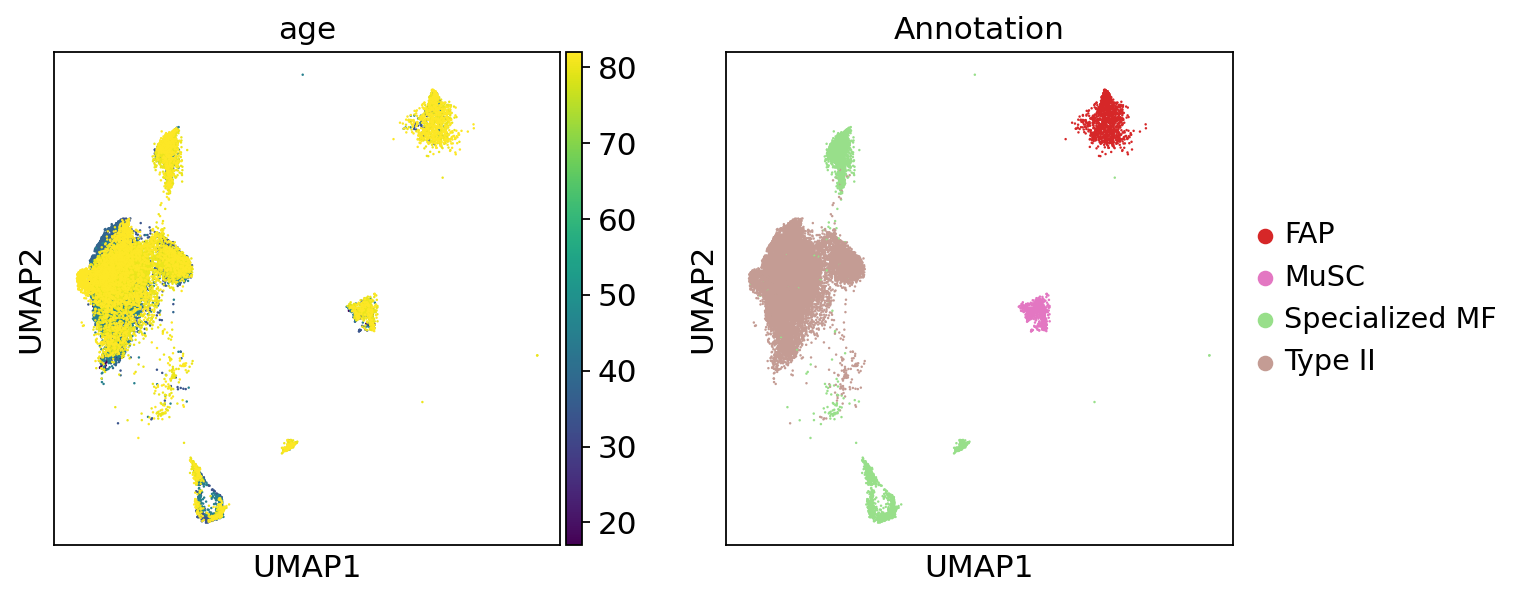

In [17]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [18]:
# make temporal info numeric
def adapt_time(x):
    if x["age_pop"] == "young_pop":
        return 1.5
    if x["age_pop"] == "old_pop":
        return 3.5
    raise ValueError

rna_adata.obs["age_pop"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [19]:
rna_adata.obs['age_pop'].value_counts()

age_pop
3.5    13081
1.5    11410
Name: count, dtype: int64

In [20]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="age_pop")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [21]:
import networkx as nx

batch_column = "age_pop"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

# if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
# n_components = nx.number_connected_components(G)
# print(f"Number of connected components: {n_components}")
# # Check sizes of each component
# sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
# print(f"Component sizes: {sizes}")

In [22]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [23]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [24]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7, batch_size=5000) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(11410, 13081)].                                


W0305 14:30:28.040732 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:30:36.677985 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:30:36.994919 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:30:37.566291 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:30:37.670086 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:30:38.288377 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:31:15.555476 3578171 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:31:15.561346 3578170 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14

### Save objects after computation

In [25]:
import cloudpickle
with open(f'{tmp_dir}/tp0_5k_type2_plus_soi.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [26]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_soi.npz"), T_15_35_csr)

W0305 14:36:07.386616 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:07.442048 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:07.461839 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:08.122276 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:08.210780 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:08.248015 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:08.285995 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:36:08.339584 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


## Visualize cell clusters of interest

In [27]:
rna_adata.obs["age"] = rna_adata.obs["age"].astype("category")
order_chronological = rna_adata.obs["age"].cat.categories.tolist()
order_chronological

[17.0, 34.0, 38.0, 45.0, 80.0, 82.0]

In [28]:
# cell types of interest
rna_adata.obs['Annotation'] = rna_adata.obs['Annotation'].astype("category")
order_cell_types = rna_adata.obs['Annotation'].cat.categories.tolist()
order_cell_types

['FAP', 'MuSC', 'Specialized MF', 'Type II']

W0305 14:38:52.378895 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.445979 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.604985 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.644139 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.687870 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.734610 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.768975 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:38:54.840829 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14

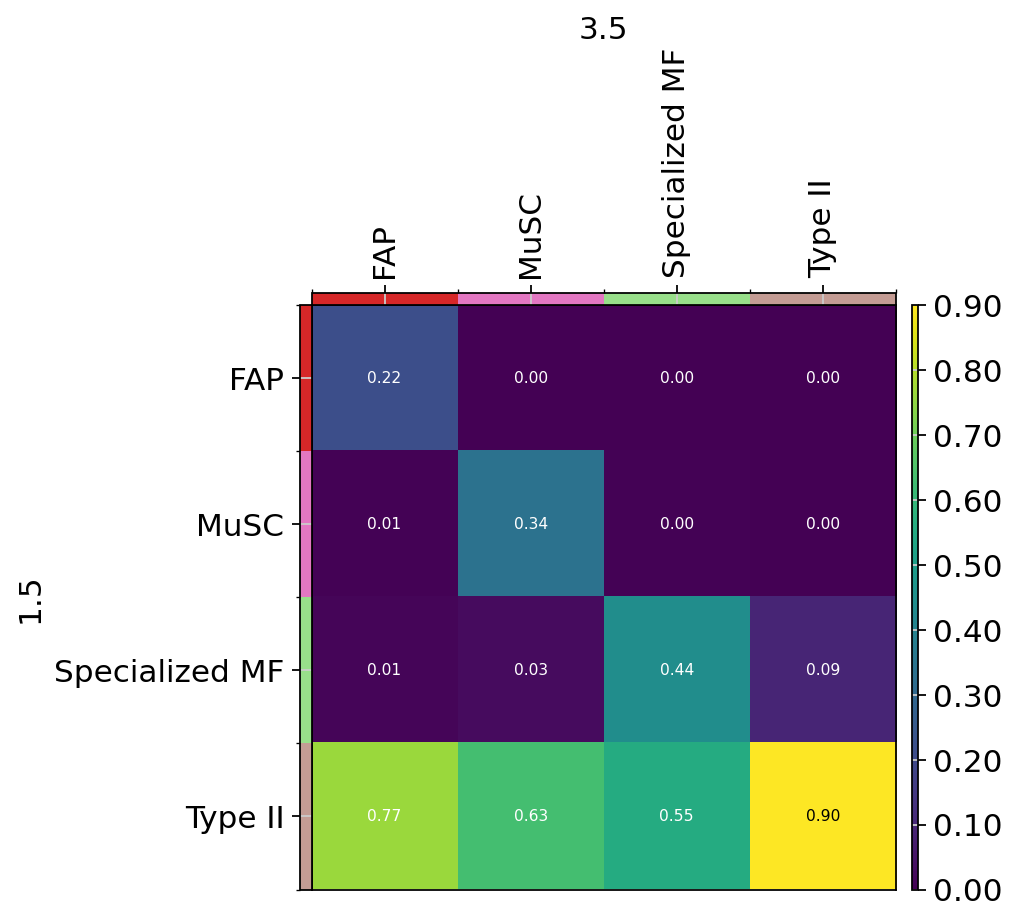

In [29]:
#aggregating the transport matrix by chronological age
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

W0305 14:40:39.918704 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:39.950939 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:40.009172 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:40.052039 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:40.119912 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:40.160065 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:40.194125 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:40:40.212922 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14

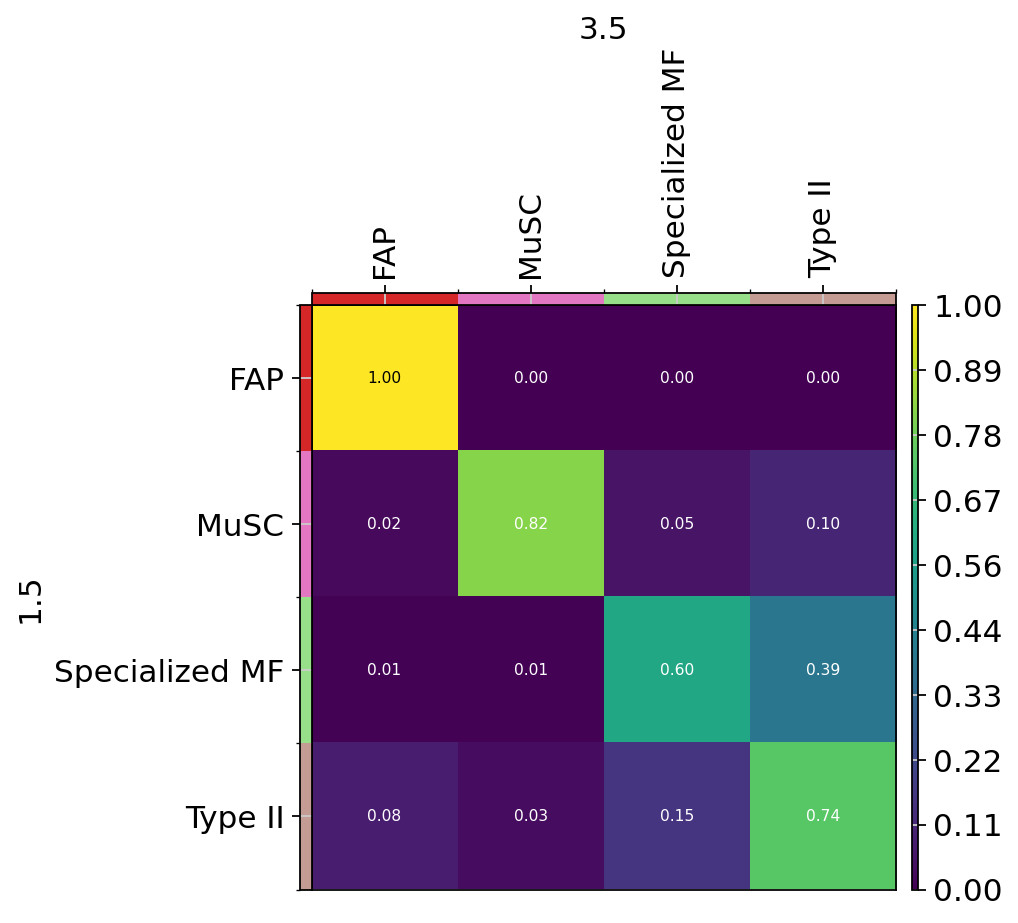

In [30]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

W0305 14:42:41.485488 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:42:41.626646 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:42:41.645170 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:42:41.663961 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:42:41.686201 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:42:41.739855 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0305 14:42:41.777262 3574527 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


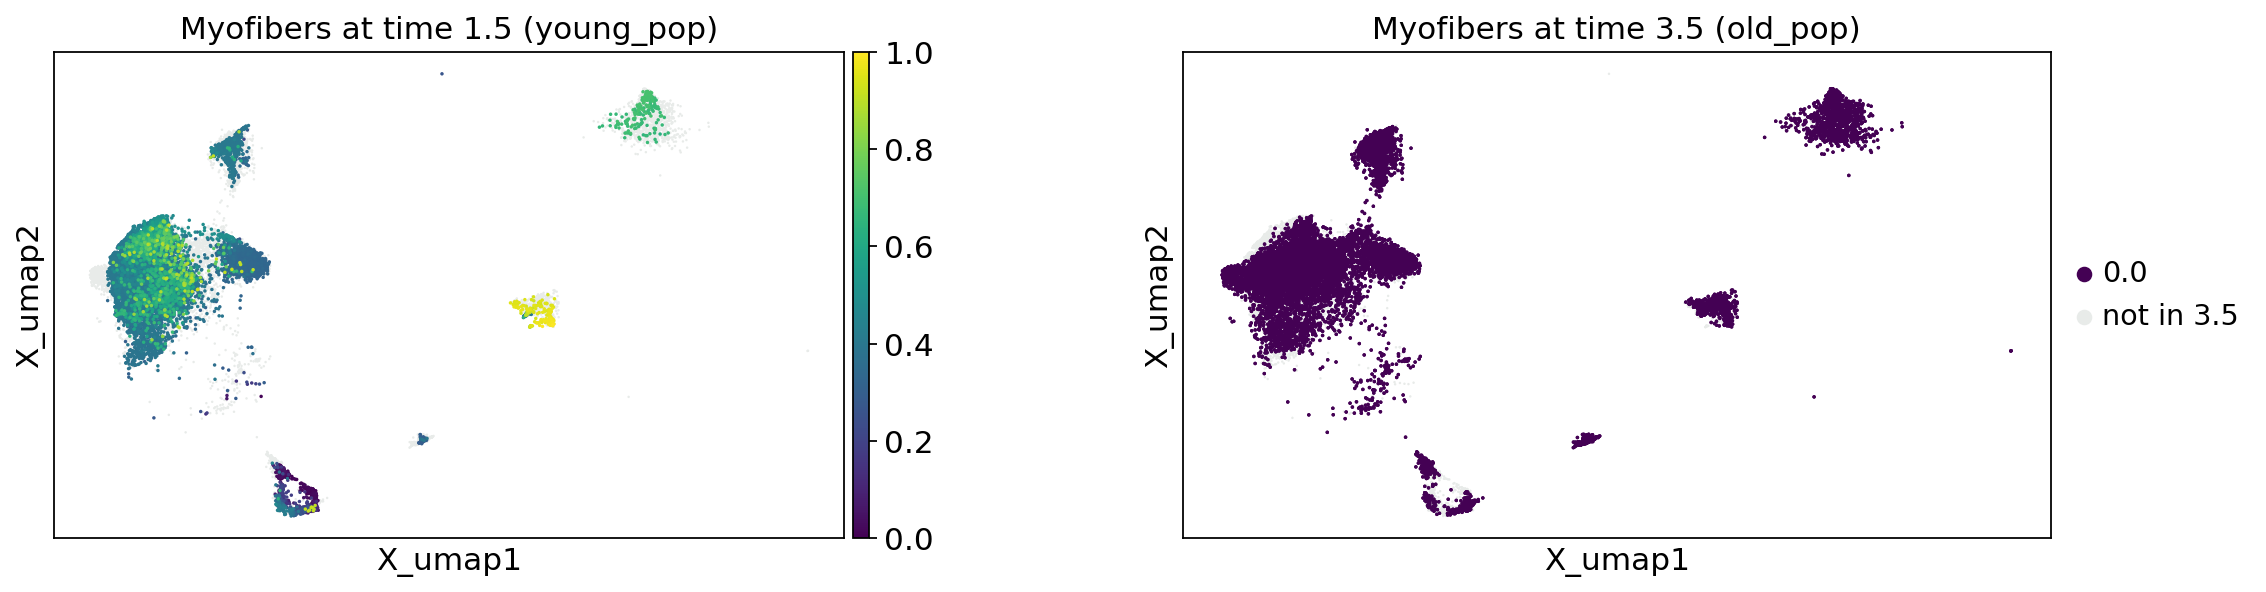

In [31]:
tp0.pull(source=1.5, target=3.5, data="Annotation")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[0],
    title=["Myofibers at time 1.5 (young_pop)"],
)

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[1],
    title=["Myofibers at time 3.5 (old_pop)"],
)

fig.subplots_adjust(wspace=0.3)

In [32]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

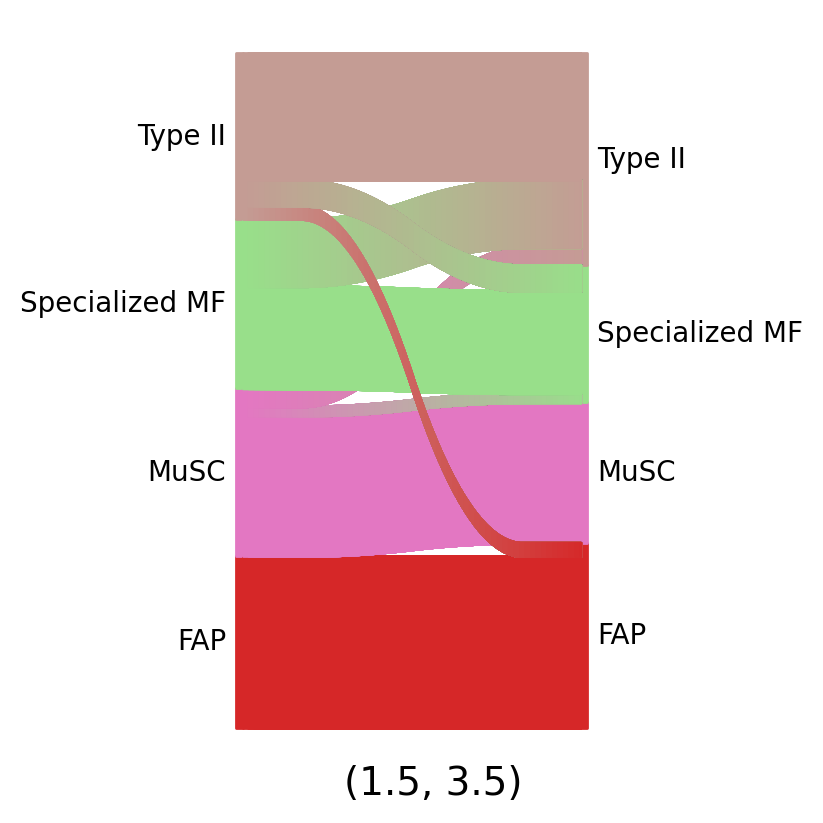

In [33]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [34]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

0.047847115 0.0 8.641517


In [35]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

normalizing counts per cell
    finished (0:00:04)


In [47]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec_mf_type2, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type II',
    young_cell_cluster='Specialized MF',
    cell_cluster_col='Annotation',
    t_young=1.5,
    t_old=3.5,
)

[pull] key='Type II_Specialized MF_pull' | weight sum = 2.0000
[subset] 1826 cells with Annotation=Specialized MF at t=1.5
count    1.826000e+03
mean     5.196622e-05
std      5.144278e-05
min      0.000000e+00
25%      6.193329e-07
50%      3.659584e-05
75%      1.065276e-04
max      1.330247e-04
Name: Type II_Specialized MF_pull, dtype: float64

[result] 44 significant drivers (qval<0.05, |corr|>0.1)


,Type II_Specialized MF_corr,Type II_Specialized MF_pval,Type II_Specialized MF_qval,Type II_Specialized MF_ci_low,Type II_Specialized MF_ci_high,significant
MEF2C,0.202806,0.000000,0.000000,0.190767,0.214785,True
SOX6,0.146501,0.000000,0.000000,0.134224,0.158734,True
NCOA3,0.131202,0.000000,0.000000,0.118873,0.143490,True
PHF20,0.124048,0.000000,0.000000,0.111697,0.136360,True
ZBTB16,0.122721,0.000000,0.000000,0.110366,0.135037,True
NFATC3,0.117706,0.000000,0.000000,0.105337,0.130039,True
MSI2,0.110654,0.000000,0.000000,0.098266,0.123007,True
GBX1,0.108355,0.000000,0.000000,0.095961,0.120715,True
GTF2IRD1,0.106695,0.000000,0.000000,0.094297,0.119060,True
TP63,0.104188,0.000000,0.000000,0.091784,0.116560,True


,Type II_Specialized MF_corr,Type II_Specialized MF_pval,Type II_Specialized MF_qval,Type II_Specialized MF_ci_low,Type II_Specialized MF_ci_high,significant
EBF1,-0.283505,0.000000,0.000000,-0.294982,-0.271947,True
EBF2,-0.278745,0.000000,0.000000,-0.290256,-0.267153,True
PLAGL1,-0.224385,0.000000,0.000000,-0.236245,-0.212458,True
SOX5,-0.207429,0.000000,0.000000,-0.219383,-0.195412,True
ESRRG,-0.197315,0.000000,0.000000,-0.209322,-0.185249,True
DAB2,-0.187931,0.000000,0.000000,-0.199984,-0.175821,True
ANXA1,-0.187139,0.000000,0.000000,-0.199196,-0.175025,True
MEOX2,-0.168438,0.000000,0.000000,-0.180581,-0.156243,True
ZNF83,-0.161743,0.000000,0.000000,-0.173914,-0.149521,True
STAT6,-0.161007,0.000000,0.000000,-0.173182,-0.148783,True
